In [1]:
import os

# 1. 填入你解压出来的文件夹名字
project_folder_name = 'Project_Folder'  # <--- 请根据第一步看到的打印结果修改这里的名字！

# 2. 检查一下是否存在，如果存在就进入
if os.path.exists(project_folder_name):
    os.chdir(project_folder_name)
    print(f"成功进入文件夹: {os.getcwd()}")
else:
    print(f"没找到 {project_folder_name}，请检查第一步打印的文件列表。")

# 3. 再次确认 utils 是否在眼前
if 'utils' in os.listdir():
    print("太棒了！找到了 utils 文件夹，现在可以运行 import 了。")
else:
    print("还是没找到 utils，请检查你的压缩包结构。")

成功进入文件夹: /home/tic041/teams/project-team-56/Tiancheng/Project_Folder
太棒了！找到了 utils 文件夹，现在可以运行 import 了。


✅ 正在处理图片: Real/bycicle.jpg
✅ 运行设备: cuda
ℹ️ 图片尺寸: 1707x1280 (已转为灰度输入)

📊 结果分析 (Sigma=25):
   PSNR (Noisy):    20.66 dB
   PSNR (Denoised): 32.09 dB


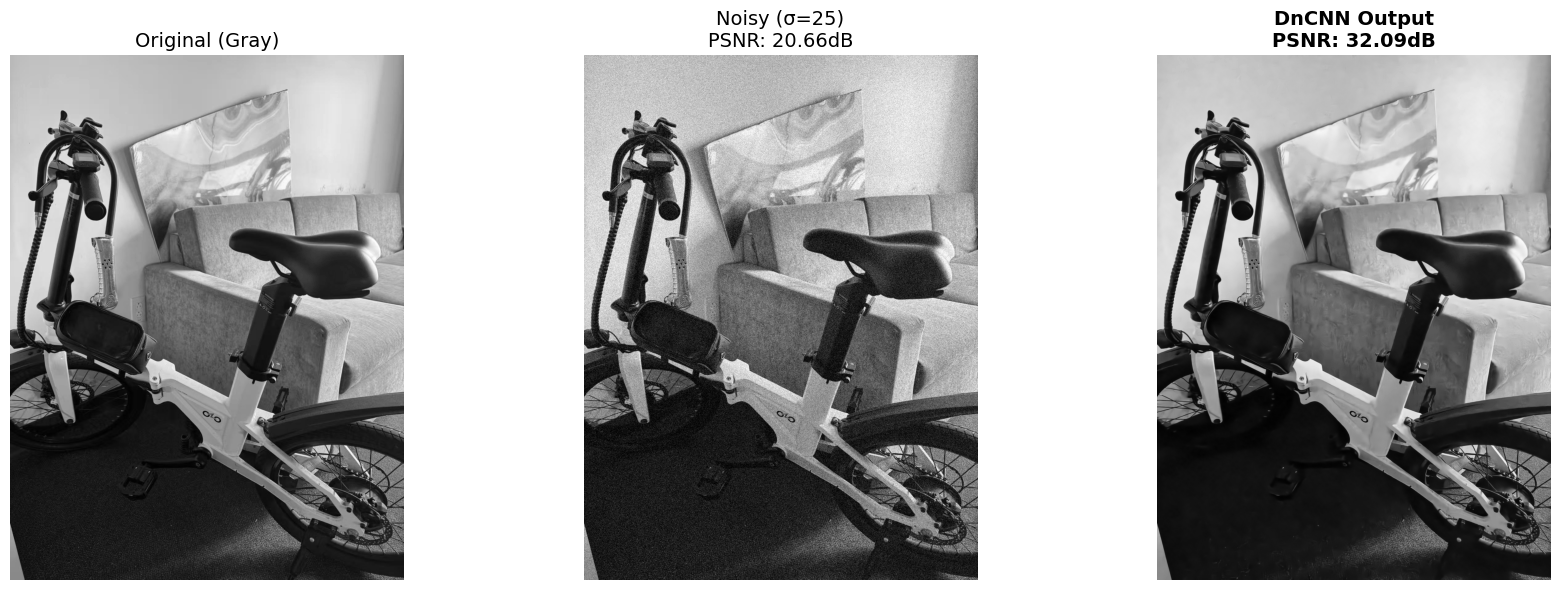

✅ 绘图完成！


In [2]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from models.network_dncnn import DnCNN as net

# ============================
# 配置部分
# ============================
# 1. 你的图片路径 (请确保路径正确，注意大小写)
IMG_PATH = "Real/bycicle.jpg"  # <--- 如果文件名是 bicycle.jpg 请修正拼写
MODEL_PATH = "model_zoo/dncnn_25.pth" # 假设模型路径在这里
SIGMA = 25 # 噪声等级

# 2. 设备配置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def main():
    # ----------------------------------------
    # 1. 检查路径
    # ----------------------------------------
    if not os.path.exists(IMG_PATH):
        print(f"❌ 错误: 找不到图片文件: {IMG_PATH}")
        print(f"   当前工作目录是: {os.getcwd()}")
        return
    
    if not os.path.exists(MODEL_PATH):
        print(f"❌ 错误: 找不到模型文件: {MODEL_PATH}")
        return

    print(f"✅ 正在处理图片: {IMG_PATH}")
    print(f"✅ 运行设备: {device}")

    # ----------------------------------------
    # 2. 加载模型 (DnCNN-25)
    # ----------------------------------------
    # 注意：这里设定 in_nc=1, out_nc=1 表示我们使用灰度模型
    model = net(in_nc=1, out_nc=1, nc=64, nb=17, act_mode='R')
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device), strict=True)
    model.eval()
    for k, v in model.named_parameters(): 
        v.requires_grad = False
    model = model.to(device)

    # ----------------------------------------
    # 3. 读取图片并预处理
    # ----------------------------------------
    # 使用 cv2 读取，flag=1 为彩色，flag=0 为灰度
    # 因为加载的是单通道模型，我们必须把图片转为灰度，否则会报错 RuntimeError
    img_bgr = cv2.imread(IMG_PATH) 
    if img_bgr is None:
        print("❌ 图片读取失败，可能是文件损坏或格式不支持。")
        return

    # 转为灰度图 (H, W)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    
    # 归一化到 [0, 1] 并转为 float32
    img_L_single = img_gray.astype(np.float32) / 255.0
    
    # 获取图片尺寸
    H, W = img_L_single.shape
    print(f"ℹ️ 图片尺寸: {H}x{W} (已转为灰度输入)")

    # ----------------------------------------
    # 4. 加噪 (Add AWGN)
    # ----------------------------------------
    np.random.seed(1) # 固定种子方便复现
    noise = np.random.normal(0, SIGMA/255.0, img_L_single.shape)
    img_noisy_single = img_L_single + noise
    img_noisy_single = np.clip(img_noisy_single, 0, 1).astype(np.float32)

    # ----------------------------------------
    # 5. 模型推理 (Denoise)
    # ----------------------------------------
    # 转为 Tensor: (1, 1, H, W)
    img_noisy_tensor = torch.from_numpy(img_noisy_single).view(1, 1, H, W).to(device)

    with torch.no_grad():
        img_denoised_tensor = model(img_noisy_tensor)
    
    # 转回 Numpy: (H, W)
    img_denoised_single = img_denoised_tensor.cpu().numpy().squeeze()
    img_denoised_single = np.clip(img_denoised_single, 0, 1)

    # ----------------------------------------
    # 6. 计算指标 (PSNR)
    # ----------------------------------------
    # 简单的 PSNR 计算函数
    def calc_psnr(img1, img2):
        mse = np.mean((img1 - img2) ** 2)
        if mse == 0: return 100
        return 20 * np.log10(1.0 / np.sqrt(mse))

    psnr_noisy = calc_psnr(img_L_single, img_noisy_single)
    psnr_denoised = calc_psnr(img_L_single, img_denoised_single)

    print(f"\n📊 结果分析 (Sigma={SIGMA}):")
    print(f"   PSNR (Noisy):    {psnr_noisy:.2f} dB")
    print(f"   PSNR (Denoised): {psnr_denoised:.2f} dB")

    # ----------------------------------------
    # 7. 可视化对比 (Matplotlib)
    # ----------------------------------------
    plt.figure(figsize=(18, 6))

    # 原图
    plt.subplot(1, 3, 1)
    plt.imshow(img_L_single, cmap='gray')
    plt.title("Original (Gray)", fontsize=14)
    plt.axis('off')

    # 加噪图
    plt.subplot(1, 3, 2)
    plt.imshow(img_noisy_single, cmap='gray')
    plt.title(f"Noisy (σ={SIGMA})\nPSNR: {psnr_noisy:.2f}dB", fontsize=14)
    plt.axis('off')

    # 降噪图
    plt.subplot(1, 3, 3)
    plt.imshow(img_denoised_single, cmap='gray')
    plt.title(f"DnCNN Output\nPSNR: {psnr_denoised:.2f}dB", fontsize=14, fontweight='bold')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
    print("✅ 绘图完成！")

if __name__ == "__main__":
    main()

Running on device: cuda
Loading DnCNN model...
Result: PSNR: 32.09 dB, SSIM: 0.8529
Saved to dncnn_bicycle_results.png


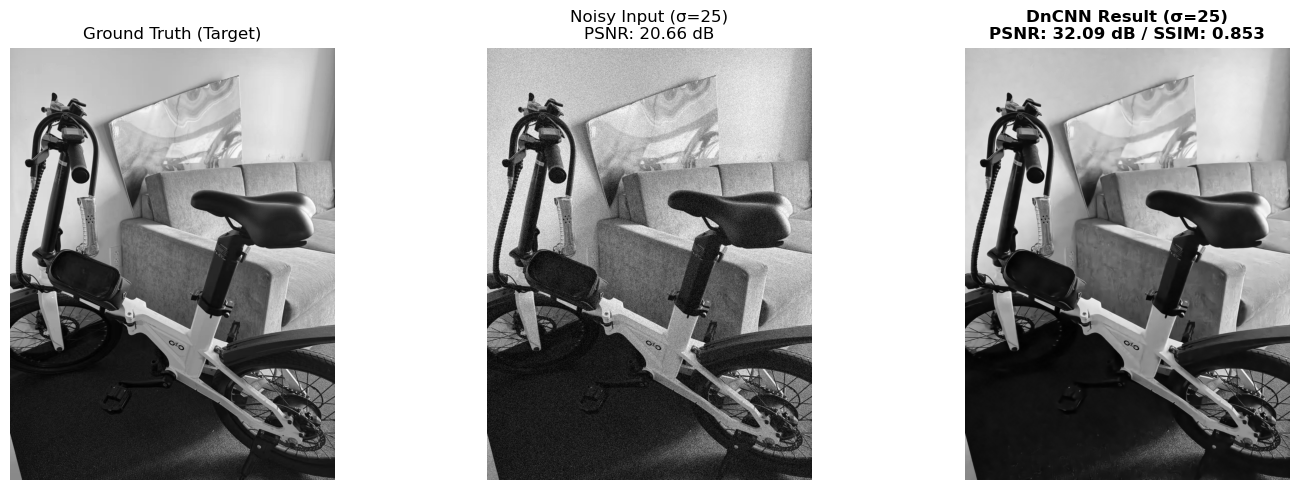

In [3]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim_func
from models.network_dncnn import DnCNN as net

# ============================
# 1. 配置参数
# ============================
IMG_PATH = "Real/bycicle.jpg"  # 请确认文件名拼写，如果是 bicycle.jpg 请修改
MODEL_PATH = "model_zoo/dncnn_25.pth"
SIGMA = 25

# ============================
# 2. 工具函数
# ============================
def calculate_psnr(img1, img2):
    # img1, img2: float32 [0, 1]
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0: return 100
    return 20 * np.log10(1.0 / np.sqrt(mse))

def calculate_ssim(img1, img2):
    # img1, img2: float32 [0, 1], shape (H, W)
    # data_range=1.0 因为我们是归一化后的 float
    return ssim_func(img1, img2, data_range=1.0)

# ============================
# 3. 主逻辑
# ============================
def main():
    # --- 环境准备 ---
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Running on device: {device}")

    if not os.path.exists(IMG_PATH):
        print(f"❌ Error: Image not found at {IMG_PATH}")
        return

    # --- 加载模型 ---
    print("Loading DnCNN model...")
    model = net(in_nc=1, out_nc=1, nc=64, nb=17, act_mode='R')
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device), strict=True)
    model.eval()
    for k, v in model.named_parameters(): v.requires_grad = False
    model = model.to(device)

    # --- 数据处理 ---
    # 1. 读取并转灰度 (Ground Truth)
    img_bgr = cv2.imread(IMG_PATH)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    img_gt = img_gray.astype(np.float32) / 255.0  # [0, 1]

    # 2. 加噪 (Noisy)
    np.random.seed(42)
    noise = np.random.normal(0, SIGMA/255.0, img_gt.shape)
    img_noisy = img_gt + noise
    img_noisy = np.clip(img_noisy, 0, 1).astype(np.float32)

    # 3. 推理 (Denoised)
    img_noisy_tensor = torch.from_numpy(img_noisy).view(1, 1, img_gt.shape[0], img_gt.shape[1]).to(device)
    with torch.no_grad():
        img_denoised_tensor = model(img_noisy_tensor)
    img_denoised = img_denoised_tensor.cpu().numpy().squeeze()
    img_denoised = np.clip(img_denoised, 0, 1)

    # --- 计算指标 ---
    psnr_n = calculate_psnr(img_gt, img_noisy)
    psnr_d = calculate_psnr(img_gt, img_denoised)
    ssim_d = calculate_ssim(img_gt, img_denoised)

    print(f"Result: PSNR: {psnr_d:.2f} dB, SSIM: {ssim_d:.4f}")

    # ============================
    # 4. 封装结果到 buffer
    # ============================
    results_buffer = []
    
    # 将本次结果存入字典，Key 必须与你的绘图代码对应
    res_data = {
        'sigma': SIGMA,
        'clean': img_gt,
        'noisy': img_noisy,
        'denoised': img_denoised,
        'psnr_noisy': psnr_n,
        'psnr_denoised': psnr_d,
        'ssim_denoised': ssim_d
    }
    results_buffer.append(res_data)

    # ============================
    # 5. 你的绘图代码 (完全复用)
    # ============================
    rows = len(results_buffer)
    cols = 3

    # 注意：如果 rows=1，plt.subplots 返回的 axes 是一个一维数组而不是二维矩阵
    # 为了兼容你的代码 axes[i][0]，我们需要 squeeze=False 或者手动处理
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows), squeeze=False)
    
    for i, res in enumerate(results_buffer):
        sigma = res['sigma']
        
        # Column 1: Ground Truth
        ax1 = axes[i][0]
        ax1.imshow(res['clean'], cmap='gray')
        ax1.set_title("Ground Truth (Target)", fontsize=12)
        ax1.axis('off')
        
        # Column 2: Noisy
        ax2 = axes[i][1]
        ax2.imshow(res['noisy'], cmap='gray')
        ax2.set_title(
            f"Noisy Input (σ={sigma})\nPSNR: {res['psnr_noisy']:.2f} dB",
            fontsize=12
        )
        ax2.axis('off')
        
        # Column 3: Result (修改了 Title 为 DnCNN 以符合当前模型)
        ax3 = axes[i][2]
        ax3.imshow(res['denoised'], cmap='gray')
        ax3.set_title(
            f"DnCNN Result (σ={sigma})\n"  # 这里的名字改成了 DnCNN
            f"PSNR: {res['psnr_denoised']:.2f} dB / "
            f"SSIM: {res['ssim_denoised']:.3f}",
            fontsize=12,
            fontweight='bold'
        )
        ax3.axis('off')

    plt.tight_layout()
    save_path = "dncnn_bicycle_results.png"
    plt.savefig(save_path)
    print(f"Saved to {save_path}")
    plt.show()

if __name__ == "__main__":
    main()